# Perfect World vs Game Industry Peers: A Financial Health Analysis

## Project Overview

This project evaluates whether Perfect World appears financially strong enough to support relatively stable long-term game operations when compared with a refined peer group of firms related to games, interactive entertainment, digital culture, media, and online services.

This project is designed as a Track 2 GitHub Data Analysis Project. It uses Python to obtain, clean, transform, analyse, and communicate financial data for a clearly defined analytical purpose.

## Analytical Problem

Many paying players spend money on in-game items, accounts, skins, characters, and other virtual content. For these users, game spending is not only a short-term entertainment cost. It may also depend on whether the game company is financially stable enough to maintain regular updates, servers, events, and long-term game services.

Therefore, the analytical problem of this project is:

**Does Perfect World appear financially strong enough, compared with similar game and digital entertainment firms, to support stable long-term game operations?**

## Target User

The target users are paying players, gaming consumers, and entry-level observers of the entertainment industry.

These users may not have advanced accounting knowledge, but they may want a simple financial signal about whether a game company looks reliable enough to support future updates, stable services, and long-term platform operation.

## Analytical Purpose

The purpose of this project is to transform company-level financial statement data into a clearer comparison between Perfect World and a refined peer group.

The analysis focuses on several financial dimensions, including growth, financial pressure, profitability, liquidity, efficiency, and operating cash-flow support. The final output provides a simple interpretation of whether Perfect World appears stronger or weaker than comparable firms from the perspective of long-term spending risk.

## Data Source

The data are obtained from WRDS / CSMAR, including the financial master table and company information table.

The financial master table is used to obtain financial statement variables such as revenue, net income, total assets, total liabilities, current assets, current liabilities, and operating cash flow. The company information table is used to identify Perfect World’s industry category and construct a relevant peer group.

Data accessed: April 2026.

In [1]:
import wrds
import pandas as pd

In [2]:
# Replace the string below with your own WRDS account name (e.g. 'jsmith').
username = "YOUR_WRDS_USERNAME"
db = wrds.Connection(wrds_username=username)

Enter your WRDS username [YOUR_WRDS_USERNAME]: gloria666
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 1. Extract and Prepare Perfect World’s Annual Financial Data

This section extracts Perfect World’s annual financial statement data from WRDS / CSMAR for the period from 2019 to 2024.

Perfect World is identified by its stock code, `002624`. The selected financial variables include revenue, net income, current assets, total assets, current liabilities, total liabilities, and operating cash flow.

After the raw data are loaded, several cleaning steps are applied. The analysis keeps only annual report data, year-end observations, and one observation for each year. This ensures that the financial indicators are calculated on a consistent annual basis.

Eight financial indicators are then constructed:

1. **Revenue growth** – measures whether the company is expanding or shrinking in sales.
2. **Debt ratio** – measures financial pressure by comparing total liabilities with total assets.
3. **Operating cash flow to assets** – measures operating cash-flow support relative to company size.
4. **Net profit margin** – measures how much profit is generated from revenue.
5. **Return on assets (ROA)** – measures how efficiently assets generate profit.
6. **Current ratio** – measures short-term liquidity and the ability to cover current liabilities.
7. **Asset turnover** – measures how efficiently assets generate revenue.
8. **Operating cash flow to net income** – measures the cash-flow support behind accounting profit.

These indicators are used because they connect directly with the target users’ concern: whether the company has enough financial strength to support long-term game services and updates.

In [11]:
# Set the target company and analysis period
stkcd = '002624'
start_date = '2019-12-31'
end_date = '2024-12-31'

# Select the key financial variables needed for this project
selected_columns = """
stkcd,
shortname,
accper,
typrep,
b001100000,
b002000000,
a001100000,
a001000000,
a002100000,
a002000000,
c001000000
"""

# Extract Perfect World's raw financial data
sql_query = f"""
SELECT {selected_columns}
FROM csmar.wrds_csmar_financial_master
WHERE stkcd = '{stkcd}'
  AND accper BETWEEN '{start_date}' AND '{end_date}'
ORDER BY accper
"""

df = db.raw_sql(sql_query, date_cols=['accper'])

# Rename columns into readable variable names
df = df.rename(columns={
    'b001100000': 'revenue',
    'b002000000': 'net_income',
    'a001100000': 'current_assets',
    'a001000000': 'total_assets',
    'a002100000': 'current_liabilities',
    'a002000000': 'total_liabilities',
    'c001000000': 'operating_cash_flow'
})

# Keep only one report type
df = df[df['typrep'] == 'A'].copy()

# Keep only year-end observations
df = df[pd.to_datetime(df['accper']).dt.strftime('%m-%d') == '12-31'].copy()

# Create year column
df['year'] = pd.to_datetime(df['accper']).dt.year

# Sort and remove duplicate firm-year observations
df = df.sort_values('accper').drop_duplicates(subset=['stkcd', 'year'])

# Construct financial indicators
df['revenue_growth'] = df['revenue'].pct_change()
df['debt_ratio'] = df['total_liabilities'] / df['total_assets']
df['ocf_to_assets'] = df['operating_cash_flow'] / df['total_assets']
df['net_profit_margin'] = df['net_income'] / df['revenue']
df['roa'] = df['net_income'] / df['total_assets']
df['current_ratio'] = df['current_assets'] / df['current_liabilities']
df['asset_turnover'] = df['revenue'] / df['total_assets']
df['ocf_to_net_income'] = df['operating_cash_flow'] / df['net_income']

# Replace infinite values caused by zero denominators
df = df.replace([float('inf'), -float('inf')], pd.NA)

# Keep only the variables needed later
df = df[['stkcd', 'shortname', 'year', 'accper',
         'revenue', 'net_income',
         'current_assets', 'total_assets',
         'current_liabilities', 'total_liabilities',
         'operating_cash_flow',
         'revenue_growth', 'debt_ratio', 'ocf_to_assets',
         'net_profit_margin', 'roa',
         'current_ratio', 'asset_turnover', 'ocf_to_net_income']]

df

,stkcd,shortname,year,accper,revenue,net_income,current_assets,total_assets,current_liabilities,total_liabilities,operating_cash_flow,revenue_growth,debt_ratio,ocf_to_assets,net_profit_margin,roa,current_ratio,asset_turnover,ocf_to_net_income
0,002624,WMSJ,2019,2019-12-31,8039021278.77,1447155065.47,10132109685.059999,16629394610.73,4799606368.97,6500647724.46,2023440592.96,<NA>,0.390913,0.121679,0.180016,0.087024,2.111029,0.483422,1.39822
10,002624,WMSJ,2020,2020-12-31,10224767171.309999,1504287486.34,7884616979.87,15506930273.09,4203704700.16,4324538166.79,3692549364.59,0.271892,0.278878,0.238123,0.147122,0.097007,1.875635,0.659368,2.454683
19,002624,WMSJ,2021,2021-12-31,8517998133.61,177362555.72,7564692644.76,17039505936.950001,4356981677.05,6535086076.11,1097681874.57,-0.166925,0.383526,0.06442,0.020822,0.010409,1.736223,0.499897,6.188916
27,002624,WMSJ,2022,2022-12-31,7670402228.08,1399589204.69,6378493052.49,15635994534.059999,4117169276.83,6159796956.09,1155208642.79,-0.099506,0.39395,0.073881,0.182466,0.089511,1.549242,0.490561,0.825391
35,002624,WMSJ,2023,2023-12-31,7790717277.28,582595567.48,6808959877.38,14488533708.41,3463910483.97,5063762756.18,761820285.9,0.015686,0.349501,0.052581,0.074781,0.040211,1.965686,0.537716,1.307631
43,002624,WMSJ,2024,2024-12-31,5570490164.67,-1400096630.81,6443668288.38,11365625431.969999,3861276875.28,4496058836.16,576532621.16,-0.284984,0.395584,0.050726,-0.251342,-0.123187,1.668792,0.490117,-0.411781


## 2. Identify Perfect World’s WRDS / CSMAR Industry Category

This section uses the WRDS / CSMAR company information table to identify Perfect World’s industry classification.

The industry category is used as the starting point for peer group construction. This step is necessary because Perfect World should not be compared with all listed companies. Instead, it should be compared with firms that operate in a broadly similar business environment.

However, the original WRDS / CSMAR industry category may still be too broad for a game-focused analysis. Therefore, the industry classification is used only as the first screening step. A further keyword-based refinement is applied in the next section to create a more relevant peer group.

In [4]:
# Load the WRDS / CSMAR company table
trd_co_full = db.get_table('csmar', 'trd_co')

# Locate Perfect World
pw_row = trd_co_full[trd_co_full['stkcd'].astype(str) == '002624'].iloc[0]

# Show key company and industry information
pw_row[['stkcd', 'conme', 'nindcd', 'nindnme', 'nnindcd', 'nnindnme']]

stkcd                               002624
conme              Perfect World Co., Ltd.
nindcd                                 G87
nindnme       Computer Application Service
nnindcd                                I64
nnindnme    Internet and Relevant Services
Name: 2467, dtype: object

## 3. Build a Refined Peer Group

This section constructs a refined peer group for Perfect World.

First, firms from the same broad WRDS / CSMAR industry category are selected as the starting pool. Then, company-name keywords are used to keep firms that are more closely related to games, interactive entertainment, digital culture, media, online services, internet businesses, or software-related activities.

The keyword screening method helps make the peer group more relevant to the analytical problem. Since Perfect World operates in online games and digital entertainment, a refined peer sample is more meaningful than a very broad industry average.

Perfect World itself is excluded from the peer group so that the peer-group benchmark is not influenced by the target company being evaluated.

In [12]:
# Use a broader but still relevant industry category as the starting pool
industry_firms = trd_co_full[trd_co_full['nindcd'] == pw_row['nindcd']].copy()
industry_firms['stkcd'] = industry_firms['stkcd'].astype(str)

# Define keywords related to games, interactive entertainment, digital culture, media, and online services
keywords = [
    'Game', 'Interactive', 'Entertainment', 'Digital Culture',
    'Digital', 'Media', 'Online', 'Internet', 'Network', 'Software',
    '游戏', '互娱', '网络', '文化', '科技', '娱乐'
]

# Refine the peer group using company-name filtering
mask = industry_firms['conme'].astype(str).str.contains('|'.join(keywords), case=False, na=False) | \
       industry_firms['stknme'].astype(str).str.contains('|'.join(keywords), case=False, na=False)

game_like_firms = industry_firms[mask].copy()

# Exclude Perfect World itself from the peer group
game_like_firms = game_like_firms[game_like_firms['stkcd'] != '002624'].copy()

print("Number of game-like firms:", game_like_firms['stkcd'].nunique())
game_like_firms[['stkcd', 'stknme', 'conme', 'nindcd', 'nindnme']].head(50)

Number of game-like firms: 87


,stkcd,stknme,conme,nindcd,nindnme
4,600652,TSYJ,"Shanghai U9 Game Co., Ltd.",G87,Computer Application Service
8,000004,*ST GH,Shenzhen Guohua Network Security Technology Co...,G87,Computer Application Service
81,600633,ZSWH,"Zhejiang Daily Digital Culture Group Co., Ltd.",G87,Computer Application Service
82,600634,TSFK,"Shanghai Fukong Interactive Entertainment Co.,...",G87,Computer Application Service
90,600640,GMWH,"New Guomai Digital Culture Co., Ltd.",G87,Computer Application Service
224,600804,TSPB,"Dr. Peng Telecom & Media Group Co., Ltd.",G87,Computer Application Service
280,600845,BXRJ,"Shanghai Baosight Software Co., Ltd.",G87,Computer Application Service
282,900926,BXB,"Shanghai Baosight Software Co., Ltd.",G87,Computer Application Service
287,600850,DKSZ,"CETC Digital Technology Co., Ltd.",G87,Computer Application Service
294,000555,SZXX,Digital China Information Service Group Compan...,G87,Computer Application Service


## 4. Extract and Prepare Peer Group Financial Data

This section extracts the annual financial statement data for the refined peer group from WRDS / CSMAR.

To ensure a fair comparison, the peer group data are processed using the same rules as Perfect World’s data. The analysis keeps annual report data, year-end observations, and one observation for each firm-year.

The same eight financial indicators are calculated for every peer firm:

1. Revenue growth
2. Debt ratio
3. Operating cash flow to assets
4. Net profit margin
5. Return on assets
6. Current ratio
7. Asset turnover
8. Operating cash flow to net income

Using the same indicators and cleaning rules is important because the comparison would be less reliable if Perfect World and the peer group were measured differently.

In [13]:
# Convert the refined peer group into a list of stock codes
industry_codes = game_like_firms['stkcd'].dropna().astype(str).unique().tolist()

# Use the same financial variables as for Perfect World
selected_columns = """
stkcd,
shortname,
accper,
typrep,
b001100000,
b002000000,
a001100000,
a001000000,
a002100000,
a002000000,
c001000000
"""

# Extract peer-group raw financial data
sql_query_industry = f"""
SELECT {selected_columns}
FROM csmar.wrds_csmar_financial_master
WHERE stkcd IN {tuple(industry_codes)}
  AND accper BETWEEN '{start_date}' AND '{end_date}'
ORDER BY stkcd, accper
"""

industry_df = db.raw_sql(sql_query_industry, date_cols=['accper'])

# Rename columns
industry_df = industry_df.rename(columns={
    'b001100000': 'revenue',
    'b002000000': 'net_income',
    'a001100000': 'current_assets',
    'a001000000': 'total_assets',
    'a002100000': 'current_liabilities',
    'a002000000': 'total_liabilities',
    'c001000000': 'operating_cash_flow'
})

# Keep only one report type
industry_df = industry_df[industry_df['typrep'] == 'A'].copy()

# Keep only year-end observations
industry_df = industry_df[pd.to_datetime(industry_df['accper']).dt.strftime('%m-%d') == '12-31'].copy()

# Create year column
industry_df['year'] = pd.to_datetime(industry_df['accper']).dt.year

# Sort and remove duplicate firm-year observations
industry_df = industry_df.sort_values(['stkcd', 'accper'])
industry_df = industry_df.drop_duplicates(subset=['stkcd', 'year'])

# Construct indicators
industry_df['revenue_growth'] = industry_df.groupby('stkcd')['revenue'].pct_change()
industry_df['debt_ratio'] = industry_df['total_liabilities'] / industry_df['total_assets']
industry_df['ocf_to_assets'] = industry_df['operating_cash_flow'] / industry_df['total_assets']
industry_df['net_profit_margin'] = industry_df['net_income'] / industry_df['revenue']
industry_df['roa'] = industry_df['net_income'] / industry_df['total_assets']
industry_df['current_ratio'] = industry_df['current_assets'] / industry_df['current_liabilities']
industry_df['asset_turnover'] = industry_df['revenue'] / industry_df['total_assets']
industry_df['ocf_to_net_income'] = industry_df['operating_cash_flow'] / industry_df['net_income']

# Replace infinite values caused by zero denominators
industry_df = industry_df.replace([float('inf'), -float('inf')], pd.NA)

# Keep final columns
industry_df = industry_df[['stkcd', 'shortname', 'year', 'accper',
                           'revenue', 'net_income',
                           'current_assets', 'total_assets',
                           'current_liabilities', 'total_liabilities',
                           'operating_cash_flow',
                           'revenue_growth', 'debt_ratio', 'ocf_to_assets',
                           'net_profit_margin', 'roa',
                           'current_ratio', 'asset_turnover', 'ocf_to_net_income']]

industry_df.head(20)

,stkcd,shortname,year,accper,revenue,net_income,current_assets,total_assets,current_liabilities,total_liabilities,operating_cash_flow,revenue_growth,debt_ratio,ocf_to_assets,net_profit_margin,roa,current_ratio,asset_turnover,ocf_to_net_income
0,000004,GNKJ,2019,2019-12-31,108246697.32,-3603992.92,480984486.77,1494490266.24,85564628.83,90033219.05,-15870920.83,<NA>,0.060243,-0.01062,-0.033294,-0.002412,5.6213,0.072431,4.403705
10,000004,GHWA,2020,2020-12-31,280531008.22,61990293.98,535289986.53,1563562870.86,103027824.96,106734607.45,3973925.97,1.59159,0.068264,0.002542,0.220975,0.039647,5.195587,0.179418,0.064106
19,000004,GHWA,2021,2021-12-31,288944181.62,-508574482.45,615772102.09,1110569957.85,156499582.02,162325227.49,3101531.46,0.02999,0.146164,0.002793,-1.760113,-0.45794,3.934657,0.260176,-0.006098
27,000004,ST GH,2022,2022-12-31,166463289.95,-595951692.72,508212687.32,575390741.06,210688325.02,222870859.44,-33042376.14,-0.423891,0.387338,-0.057426,-3.580079,-1.035734,2.412154,0.289305,0.055445
35,000004,GHWA,2023,2023-12-31,110048548.32,-160126339.18,324289904.77,413449330.43,195004613.58,219580322.33,-36050910.29,-0.338902,0.531094,-0.087195,-1.455052,-0.387294,1.662986,0.266172,0.22514
43,000004,GHWA,2024,2024-12-31,98660353.71,-137217470.76,174915979.7,311208761.2,201231027.04,238295594.25,-16671888.17,-0.103483,0.76571,-0.053571,-1.390807,-0.440918,0.86923,0.317023,0.1215
45,000555,SZXX,2019,2019-12-31,10146008170.91,381552908.39,7777475968.78,10755502029.77,5351464171.85,5433177976.15,289967552.2,<NA>,0.505153,0.02696,0.037606,0.035475,1.453336,0.943332,0.759967
55,000555,SZXX,2020,2020-12-31,10685976832.0,466382950.29,9320042082.139999,12051862835.52,6309209567.23,6365995240.28,321856742.57,0.05322,0.528217,0.026706,0.043644,0.038698,1.477212,0.886666,0.690113
64,000555,SZXX,2021,2021-12-31,11355684728.549999,387843470.71,9636840041.66,12421706003.16,6287187322.6,6395557849.3,371594043.13,0.062672,0.51487,0.029915,0.034154,0.031223,1.532774,0.914181,0.958103
72,000555,SZXX,2022,2022-12-31,11999256671.68,206442224.23,9737084374.25,12439806587.42,6155151780.57,6305807855.83,201251232.29,0.056674,0.506906,0.016178,0.017205,0.016595,1.581941,0.964585,0.974855


## 5. Calculate Peer Group Averages

This section calculates the yearly peer-group average for all selected indicators.

These yearly averages serve as the benchmark against which Perfect World will be compared. They allow each annual value of Perfect World to be interpreted relative to the average level of the refined peer group in the same year.

Using yearly peer averages is useful because it avoids comparing one company’s annual performance with an overall benchmark that ignores time differences. This makes the comparison more consistent across the analysis period.

In [14]:
# Calculate yearly peer-group averages
industry_avg = industry_df.groupby('year')[
    [
        'revenue_growth',
        'debt_ratio',
        'ocf_to_assets',
        'net_profit_margin',
        'roa',
        'current_ratio',
        'asset_turnover',
        'ocf_to_net_income'
    ]
].mean().reset_index()

# Rename peer-group average columns for clarity
industry_avg = industry_avg.rename(columns={
    'revenue_growth': 'revenue_growth_industry',
    'debt_ratio': 'debt_ratio_industry',
    'ocf_to_assets': 'ocf_to_assets_industry',
    'net_profit_margin': 'net_profit_margin_industry',
    'roa': 'roa_industry',
    'current_ratio': 'current_ratio_industry',
    'asset_turnover': 'asset_turnover_industry',
    'ocf_to_net_income': 'ocf_to_net_income_industry'
})

industry_avg

,year,revenue_growth_industry,debt_ratio_industry,ocf_to_assets_industry,net_profit_margin_industry,roa_industry,current_ratio_industry,asset_turnover_industry,ocf_to_net_income_industry
0,2019,<NA>,0.429133,0.049552,-0.656313,-0.067662,3.851709,0.531119,0.748737
1,2020,0.075846,0.399976,0.055686,-0.101466,0.015811,3.560526,0.567058,0.957745
2,2021,0.196085,0.344303,0.034329,-0.000068,0.030043,4.011781,0.537996,0.389106
3,2022,0.009709,0.344001,0.031649,-0.140104,-0.014097,3.894004,0.529154,3.059007
4,2023,-0.037156,0.324819,0.032394,-0.202653,-0.00809,3.816057,0.491288,1.822114
5,2024,0.074511,0.346201,0.017082,-0.084563,-0.018743,3.737207,0.466929,0.844778


## 5. Build the Comparison Table

This section merges Perfect World’s annual data with the yearly peer-group averages.

The result is a comparison table that allows each indicator of Perfect World to be directly matched with the peer-group benchmark in the same year. This combined table is then used for chart construction, summary statistics, and the final interpretation.

In [9]:
# Merge Perfect World's data with peer-group yearly averages
comparison = df[['year',
                 'revenue_growth',
                 'debt_ratio',
                 'ocf_to_assets',
                 'net_profit_margin',
                 'roa',
                 'current_ratio',
                 'asset_turnover',
                 'ocf_to_net_income']].merge(
    industry_avg,
    on='year',
    how='inner'
)

# Rename company columns for clarity
comparison = comparison.rename(columns={
    'revenue_growth': 'revenue_growth_company',
    'debt_ratio': 'debt_ratio_company',
    'ocf_to_assets': 'ocf_to_assets_company',
    'net_profit_margin': 'net_profit_margin_company',
    'roa': 'roa_company',
    'current_ratio': 'current_ratio_company',
    'asset_turnover': 'asset_turnover_company',
    'ocf_to_net_income': 'ocf_to_net_income_company'
})

comparison

,year,revenue_growth_company,debt_ratio_company,ocf_to_assets_company,net_profit_margin_company,roa_company,current_ratio_company,asset_turnover_company,ocf_to_net_income_company,revenue_growth_industry,debt_ratio_industry,ocf_to_assets_industry,net_profit_margin_industry,roa_industry,current_ratio_industry,asset_turnover_industry,ocf_to_net_income_industry
0,2019,<NA>,0.390913,0.121679,0.180016,0.087024,2.111029,0.483422,1.39822,<NA>,0.429133,0.049552,-0.656313,-0.067662,3.851709,0.531119,0.748737
1,2020,0.271892,0.278878,0.238123,0.147122,0.097007,1.875635,0.659368,2.454683,0.075846,0.399976,0.055686,-0.101466,0.015811,3.560526,0.567058,0.957745
2,2021,-0.166925,0.383526,0.06442,0.020822,0.010409,1.736223,0.499897,6.188916,0.196085,0.344303,0.034329,-0.000068,0.030043,4.011781,0.537996,0.389106
3,2022,-0.099506,0.39395,0.073881,0.182466,0.089511,1.549242,0.490561,0.825391,0.009709,0.344001,0.031649,-0.140104,-0.014097,3.894004,0.529154,3.059007
4,2023,0.015686,0.349501,0.052581,0.074781,0.040211,1.965686,0.537716,1.307631,-0.037156,0.324819,0.032394,-0.202653,-0.00809,3.816057,0.491288,1.822114
5,2024,-0.284984,0.395584,0.050726,-0.251342,-0.123187,1.668792,0.490117,-0.411781,0.074511,0.346201,0.017082,-0.084563,-0.018743,3.737207,0.466929,0.844778


## 6. Visualise the Results

This section compares Perfect World with the refined peer group from multiple perspectives.

The line charts show time trends.  
The bar chart summarises overall average differences.  
The horizontal bar chart focuses on the latest year.  
The scatter plot shows the relationship between growth and financial pressure.

Together, these outputs provide evidence on growth, financial pressure, profitability, liquidity, efficiency, and cash support rather than relying on a single dimension of comparison.

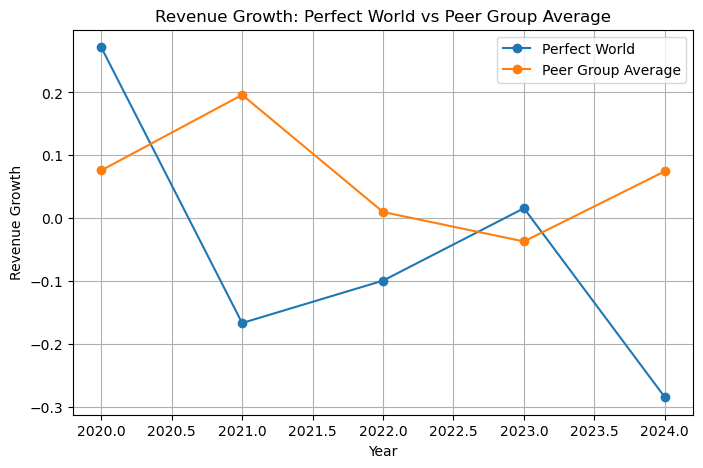

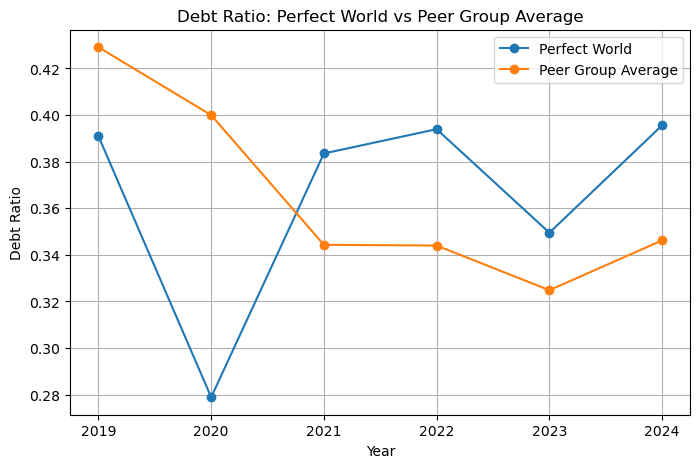

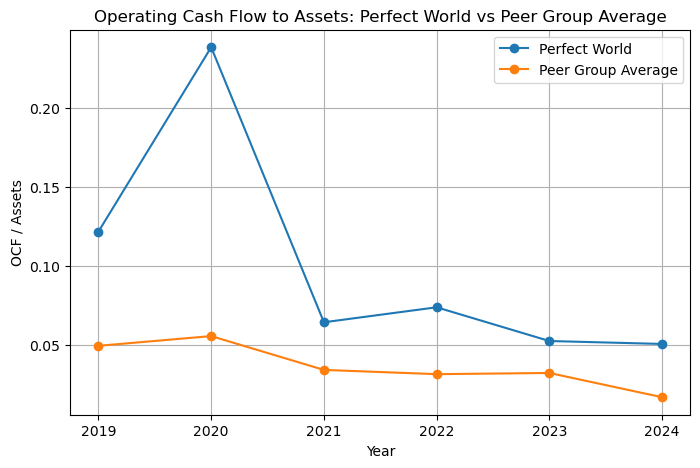

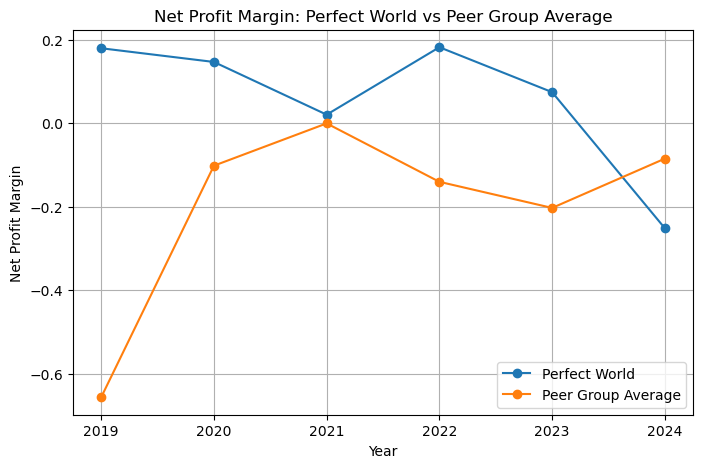

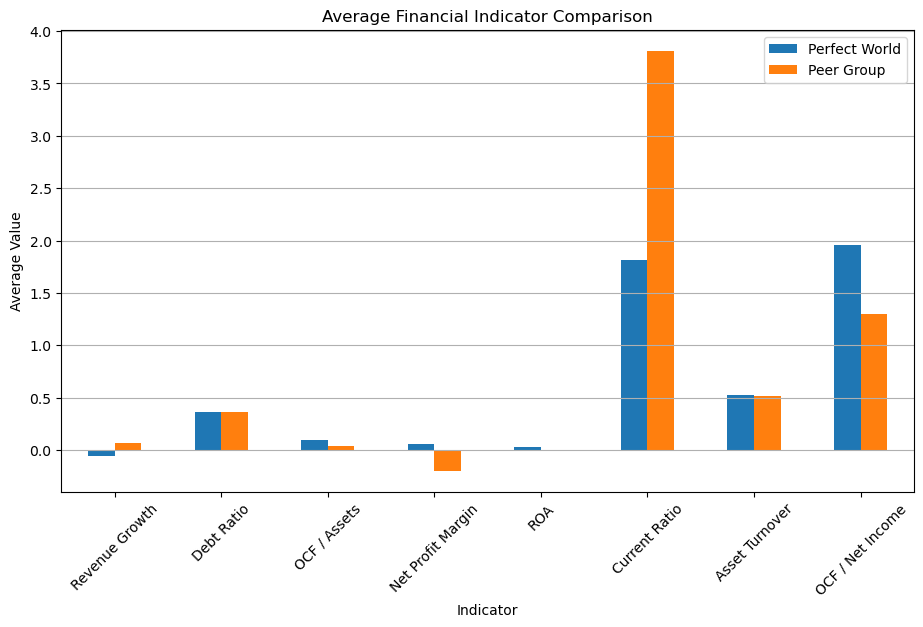

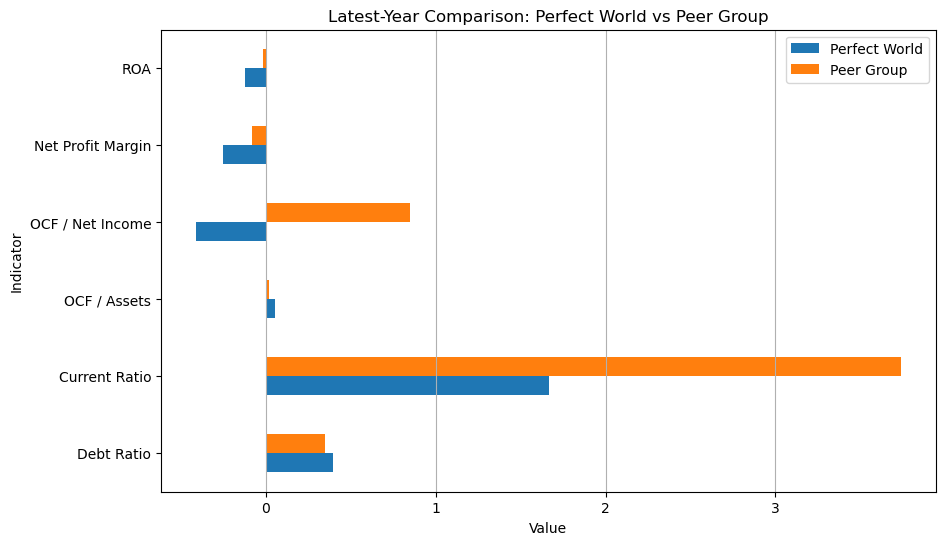

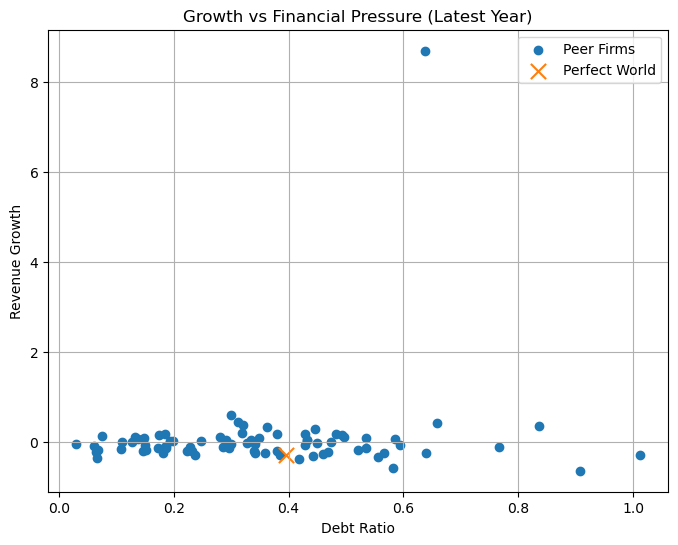

,Indicator,Perfect World Avg,Peer Group Avg
0,Revenue Growth,-0.052767,0.063799
1,Debt Ratio,0.365392,0.364739
2,OCF / Assets,0.100235,0.036782
3,Net Profit Margin,0.058978,-0.197528
4,ROA,0.033496,-0.010456
5,Current Ratio,1.817768,3.811881
6,Asset Turnover,0.526847,0.520591
7,OCF / Net Income,1.960510,1.303581


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average values for comparison
avg_company_growth = comparison['revenue_growth_company'].mean()
avg_ind_growth = comparison['revenue_growth_industry'].mean()

avg_company_debt = comparison['debt_ratio_company'].mean()
avg_ind_debt = comparison['debt_ratio_industry'].mean()

avg_company_ocf = comparison['ocf_to_assets_company'].mean()
avg_ind_ocf = comparison['ocf_to_assets_industry'].mean()

avg_company_margin = comparison['net_profit_margin_company'].mean()
avg_ind_margin = comparison['net_profit_margin_industry'].mean()

avg_company_roa = comparison['roa_company'].mean()
avg_ind_roa = comparison['roa_industry'].mean()

avg_company_current = comparison['current_ratio_company'].mean()
avg_ind_current = comparison['current_ratio_industry'].mean()

avg_company_turnover = comparison['asset_turnover_company'].mean()
avg_ind_turnover = comparison['asset_turnover_industry'].mean()

avg_company_ocfni = comparison['ocf_to_net_income_company'].mean()
avg_ind_ocfni = comparison['ocf_to_net_income_industry'].mean()

# Chart 1: Revenue Growth Trend
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['revenue_growth_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['revenue_growth_industry'], marker='o', label='Peer Group Average')
plt.title('Revenue Growth: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Revenue Growth')
plt.legend()
plt.grid(True)
plt.show()

# Chart 2: Debt Ratio Trend
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['debt_ratio_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['debt_ratio_industry'], marker='o', label='Peer Group Average')
plt.title('Debt Ratio: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Debt Ratio')
plt.legend()
plt.grid(True)
plt.show()

# Chart 3: Operating Cash Flow to Assets Trend
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['ocf_to_assets_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['ocf_to_assets_industry'], marker='o', label='Peer Group Average')
plt.title('Operating Cash Flow to Assets: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('OCF / Assets')
plt.legend()
plt.grid(True)
plt.show()

# Chart 4: Net Profit Margin Trend
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['net_profit_margin_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['net_profit_margin_industry'], marker='o', label='Peer Group Average')
plt.title('Net Profit Margin: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Net Profit Margin')
plt.legend()
plt.grid(True)
plt.show()

# Chart 5: Average Financial Indicator Comparison
summary_df = pd.DataFrame({
    'Indicator': [
        'Revenue Growth', 'Debt Ratio', 'OCF / Assets', 'Net Profit Margin',
        'ROA', 'Current Ratio', 'Asset Turnover', 'OCF / Net Income'
    ],
    'Perfect World': [
        avg_company_growth, avg_company_debt, avg_company_ocf, avg_company_margin,
        avg_company_roa, avg_company_current, avg_company_turnover, avg_company_ocfni
    ],
    'Peer Group': [
        avg_ind_growth, avg_ind_debt, avg_ind_ocf, avg_ind_margin,
        avg_ind_roa, avg_ind_current, avg_ind_turnover, avg_ind_ocfni
    ]
})

summary_df = summary_df.set_index('Indicator')

summary_df.plot(kind='bar', figsize=(11, 6))
plt.title('Average Financial Indicator Comparison')
plt.xlabel('Indicator')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

# Chart 6: Latest-Year Comparison
latest = comparison[comparison['year'] == comparison['year'].max()]

latest_df = pd.DataFrame({
    'Indicator': ['Debt Ratio', 'Current Ratio', 'OCF / Assets', 'OCF / Net Income', 'Net Profit Margin', 'ROA'],
    'Perfect World': [
        latest['debt_ratio_company'].values[0],
        latest['current_ratio_company'].values[0],
        latest['ocf_to_assets_company'].values[0],
        latest['ocf_to_net_income_company'].values[0],
        latest['net_profit_margin_company'].values[0],
        latest['roa_company'].values[0]
    ],
    'Peer Group': [
        latest['debt_ratio_industry'].values[0],
        latest['current_ratio_industry'].values[0],
        latest['ocf_to_assets_industry'].values[0],
        latest['ocf_to_net_income_industry'].values[0],
        latest['net_profit_margin_industry'].values[0],
        latest['roa_industry'].values[0]
    ]
})

latest_df = latest_df.set_index('Indicator')

latest_df.plot(kind='barh', figsize=(10, 6))
plt.title('Latest-Year Comparison: Perfect World vs Peer Group')
plt.xlabel('Value')
plt.ylabel('Indicator')
plt.grid(True, axis='x')
plt.show()

# Chart 7: Growth vs Financial Pressure
peer_latest = industry_df[industry_df['year'] == industry_df['year'].max()].copy()
pw_latest = df[df['year'] == df['year'].max()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(peer_latest['debt_ratio'], peer_latest['revenue_growth'], label='Peer Firms')
plt.scatter(pw_latest['debt_ratio'], pw_latest['revenue_growth'], s=120, marker='x', label='Perfect World')
plt.title('Growth vs Financial Pressure (Latest Year)')
plt.xlabel('Debt Ratio')
plt.ylabel('Revenue Growth')
plt.legend()
plt.grid(True)
plt.show()

# Summary Table
summary_table = pd.DataFrame({
    'Indicator': [
        'Revenue Growth', 'Debt Ratio', 'OCF / Assets', 'Net Profit Margin',
        'ROA', 'Current Ratio', 'Asset Turnover', 'OCF / Net Income'
    ],
    'Perfect World Avg': [
        avg_company_growth, avg_company_debt, avg_company_ocf, avg_company_margin,
        avg_company_roa, avg_company_current, avg_company_turnover, avg_company_ocfni
    ],
    'Peer Group Avg': [
        avg_ind_growth, avg_ind_debt, avg_ind_ocf, avg_ind_margin,
        avg_ind_roa, avg_ind_current, avg_ind_turnover, avg_ind_ocfni
    ]
})

summary_table

## 7. Summarise the Average Differences

This section prints the average value of each financial indicator for Perfect World and for the refined peer group over the full analysis period.

The printed results provide a direct numerical comparison between the target company and the peer-group benchmark. This helps users quickly see where Perfect World performs better or worse than comparable firms.

These average values summarise the overall financial pattern across the analysis period. They are also used in the final rule-based interpretation to translate multiple financial ratios into a simpler financial health signal.

In [26]:
print("Average revenue growth - Perfect World:", round(avg_company_growth, 4))
print("Average revenue growth - Peer group:", round(avg_ind_growth, 4))
print("Average debt ratio - Perfect World:", round(avg_company_debt, 4))
print("Average debt ratio - Peer group:", round(avg_ind_debt, 4))
print("Average OCF/Assets - Perfect World:", round(avg_company_ocf, 4))
print("Average OCF/Assets - Peer group:", round(avg_ind_ocf, 4))
print("Average net profit margin - Perfect World:", round(avg_company_margin, 4))
print("Average net profit margin - Peer group:", round(avg_ind_margin, 4))
print("Average ROA - Perfect World:", round(avg_company_roa, 4))
print("Average ROA - Peer group:", round(avg_ind_roa, 4))
print("Average current ratio - Perfect World:", round(avg_company_current, 4))
print("Average current ratio - Peer group:", round(avg_ind_current, 4))
print("Average asset turnover - Perfect World:", round(avg_company_turnover, 4))
print("Average asset turnover - Peer group:", round(avg_ind_turnover, 4))
print("Average OCF/Net Income - Perfect World:", round(avg_company_ocfni, 4))
print("Average OCF/Net Income - Peer group:", round(avg_ind_ocfni, 4))

Average revenue growth - Perfect World: -0.0528
Average revenue growth - Peer group: 0.0638
Average debt ratio - Perfect World: 0.3654
Average debt ratio - Peer group: 0.3647
Average OCF/Assets - Perfect World: 0.1002
Average OCF/Assets - Peer group: 0.0368
Average net profit margin - Perfect World: 0.059
Average net profit margin - Peer group: -0.1975
Average ROA - Perfect World: 0.0335
Average ROA - Peer group: -0.0105
Average current ratio - Perfect World: 1.8178
Average current ratio - Peer group: 3.8119
Average asset turnover - Perfect World: 0.5268
Average asset turnover - Peer group: 0.5206
Average OCF/Net Income - Perfect World: 1.9605
Average OCF/Net Income - Peer group: 1.3036


## 8. Rule-Based Summary Interpretation

This section uses a simple rule-based scoring method to translate multiple financial comparisons into an easy-to-understand summary.

The score starts from zero. Perfect World receives one point when it performs better than the refined peer-group average in one financial dimension. For example, higher revenue growth, stronger operating cash-flow support, higher profitability, stronger liquidity, stronger asset turnover, and better cash-flow quality are treated as positive signals. A lower debt ratio is also treated as a positive signal because it suggests lower financial pressure.

The total score is then converted into a simple overall interpretation. This interpretation is designed for the target users, including paying players, gaming consumers, and entry-level entertainment industry observers.

This method is not a formal predictive model. Instead, it is a communication tool that helps users understand the overall financial signal without needing to interpret every financial ratio separately.

In [27]:
# Start the summary score at zero
score = 0

# Add one point if Perfect World shows stronger average revenue growth
if avg_company_growth > avg_ind_growth:
    score += 1

# Add one point if Perfect World shows a lower average debt ratio
# A lower debt ratio is interpreted as lower financial pressure
if avg_company_debt < avg_ind_debt:
    score += 1

# Add one point if Perfect World shows stronger operating cash flow support
if avg_company_ocf > avg_ind_ocf:
    score += 1

# Add one point if Perfect World shows a higher average net profit margin
if avg_company_margin > avg_ind_margin:
    score += 1

# Add one point if Perfect World shows a higher average ROA
if avg_company_roa > avg_ind_roa:
    score += 1

# Add one point if Perfect World shows a stronger current ratio
if avg_company_current > avg_ind_current:
    score += 1

# Add one point if Perfect World shows stronger asset turnover
if avg_company_turnover > avg_ind_turnover:
    score += 1

# Add one point if Perfect World shows better cash-flow quality
if avg_company_ocfni > avg_ind_ocfni:
    score += 1

# Translate the total score into a simple overall interpretation
if score >= 6:
    conclusion = "Perfect World appears financially stronger than the refined peer group average and may present relatively lower long-term spending risk for paying players."
elif score >= 4:
    conclusion = "Perfect World shows moderately strong financial performance relative to the refined peer group, suggesting moderate to relatively lower long-term spending risk."
elif score >= 2:
    conclusion = "Perfect World shows mixed financial performance relative to the refined peer group, suggesting moderate long-term spending risk."
else:
    conclusion = "Perfect World appears financially weaker than the refined peer group average, which may indicate relatively higher long-term spending risk for paying players."

# Display the final summary interpretation
print(conclusion)

Perfect World shows moderately strong financial performance relative to the refined peer group, suggesting moderate to relatively lower long-term spending risk.


In [9]:
db.close()